In [13]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

(11610, 8) (5160, 8) (3870, 8)


In [15]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

In [16]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [17]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [18]:
len(train_loader)

363

In [84]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs=20):

	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : []
	}

	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		model.train()
		for X_batch, y_batch in train_loader:
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)

		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation
		model.eval()
		metric.reset()

		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

	return history

In [85]:
def plot_history(history, metric, n_epoch):
	x_axis_values = np.arange(n_epoch) + 1
	plt.plot(x_axis_values, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
	plt.plot(x_axis_values, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
	plt.legend()
	plt.grid()
	plt.xlabel('Epochs')
	plt.ylabel(metric.__class__.__name__)
	plt.show()

Epoch: 1/30, Loss: 1.193, Train Metric: 0.849, Valid Metric: 0.646
Epoch: 2/30, Loss: 0.593, Train Metric: 0.576, Valid Metric: 0.515
Epoch: 3/30, Loss: 0.482, Train Metric: 0.505, Valid Metric: 0.486
Epoch: 4/30, Loss: 0.462, Train Metric: 0.492, Valid Metric: 0.481
Epoch: 5/30, Loss: 0.451, Train Metric: 0.484, Valid Metric: 0.478
Epoch: 6/30, Loss: 0.44, Train Metric: 0.477, Valid Metric: 0.473
Epoch: 7/30, Loss: 0.433, Train Metric: 0.473, Valid Metric: 0.451
Epoch: 8/30, Loss: 0.427, Train Metric: 0.468, Valid Metric: 0.459
Epoch: 9/30, Loss: 0.42, Train Metric: 0.463, Valid Metric: 0.447
Epoch: 10/30, Loss: 0.415, Train Metric: 0.46, Valid Metric: 0.456
Epoch: 11/30, Loss: 0.41, Train Metric: 0.457, Valid Metric: 0.437
Epoch: 12/30, Loss: 0.407, Train Metric: 0.456, Valid Metric: 0.437
Epoch: 13/30, Loss: 0.405, Train Metric: 0.454, Valid Metric: 0.432
Epoch: 14/30, Loss: 0.401, Train Metric: 0.452, Valid Metric: 0.463
Epoch: 15/30, Loss: 0.397, Train Metric: 0.449, Valid Metric:

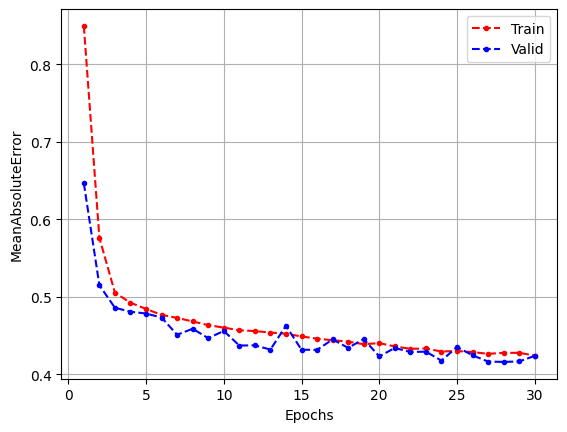

In [90]:
learning_rate = 0.05
model = nn.Sequential(
	nn.Linear(in_features=8, out_features=50), 
	nn.Sigmoid(),
	nn.Linear(in_features=50, out_features=100), 
	nn.Sigmoid(),
	nn.Linear(in_features=100, out_features=1)
)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=model.parameters())
metric = torchmetrics.MeanAbsoluteError()

n_epoch = 30

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epoch)
plot_history(history, metric, n_epoch)

In [92]:
metric.reset()

with torch.inference_mode():
	for X_batch_test, y_batch_test in test_loader:
		y_pred_test = model(X_batch_test)
		metric.update(y_pred_test, y_batch_test)

In [94]:
avg_metric_test = metric.compute().item()
avg_metric_test

0.42171066999435425

In [107]:
X_batch_test, y_batch_test = next(iter(test_loader))
X_new = X_batch_test[:2, :]
# y_new = y_batch_test[:2, :]

with torch.inference_mode():
	prices = model(X_new)
	

In [108]:
prices

tensor([[3.9145],
        [5.0887]])